#**Implementación Gradiente Descendente en Modelo de Regresión Lineal**

-Librerias necesarias

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

-Comprobacion de correlación entre los datos

In [117]:
datos = {"x": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
"y": [5, 7, 8, 11, 12, 14, 15, 17, 20, 19, 22, 24, 25, 27, 29, 30, 34, 33, 36, 38, 39, 42, 41, 44, 47, 48, 50, 51, 54, 55]}

In [118]:
df = pd.DataFrame(datos)

In [119]:
df.head()

,x,y
0,1,5
1,2,7
2,3,8
3,4,11
4,5,12


In [120]:
#correlación
df.corr()

,x,y
x,1.000000,0.998786
y,0.998786,1.000000


#**Gradient Descent:**

In [121]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])
y = np.array([5, 7, 8, 11, 12, 14, 15, 17, 20, 19, 22, 24, 25, 27, 29, 30, 34, 33, 36, 38, 39, 42, 41, 44, 47, 48, 50, 51, 54, 55])

In [122]:
b0 = 0
b1 = 0
eta = 0.001
n = len(x)

epsilon = 1e-6

In [123]:
global_min_error = np.inf
error_anterior = np.inf

-Iteraciones hasta encontrar los mejores beta:

In [124]:
while True:
  y_pred = b0 + b1*x
  temp_error = 1/n * sum((y-y_pred)**2)

  if temp_error < global_min_error:
    global_min_error = temp_error
    mejor_b0 = b0
    mejor_b1 = b1

  if abs(temp_error - error_anterior) < epsilon:
    break

  db0 = (-2/n) * sum(y-y_pred)
  db1 = (-2/n) * sum(x*(y-y_pred))

  b0, b1 = b0-eta*db0 , b1-eta*db1

  error_anterior = temp_error


print(f"Los Betas óptimos son:\nb0: {mejor_b0}\nb1: {mejor_b1}")
print(f"Mejor error: {global_min_error}")



Los Betas óptimos son:
b0: 3.2024174739282514
b1: 1.7214065758864885
Mejor error: 0.5389244212206054


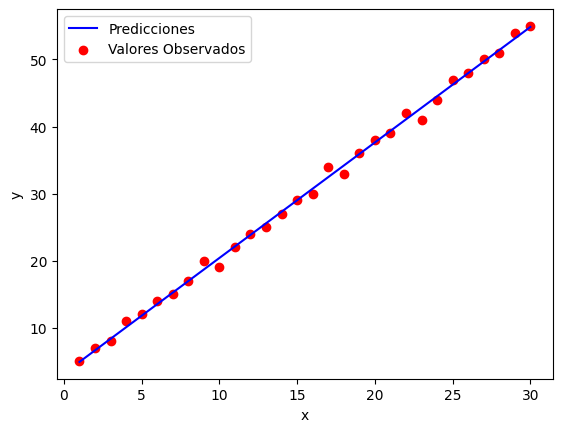

In [125]:
plt.plot(x, mejor_b0 + mejor_b1*x, color="blue", label="Predicciones")
plt.scatter(x, y, color="Red", label="Valores Observados")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

#**-Comprobación de resultados usando la libreria SKLearn:**

-Comparación de betas.

In [126]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(x.reshape(-1, 1), y)

print(f"b0: {modelo.intercept_}")
print(f"b1: {modelo.coef_[0]}")

b0: 3.268965517241387
b1: 1.7181312569521685


In [127]:
print(f"Mi b0: {mejor_b0}")
print(f"Sklearn b0: {modelo.intercept_} \n")

print(f"Mi b1: {mejor_b1}")
print(f"Sklearn b1: {modelo.coef_[0]}")

Mi b0: 3.2024174739282514
Sklearn b0: 3.268965517241387 

Mi b1: 1.7214065758864885
Sklearn b1: 1.7181312569521685


-Comparación de errores:

In [128]:
from sklearn.metrics import mean_squared_error

y_pred_sklearn = modelo.predict(x.reshape(-1, 1))

mse = mean_squared_error(y, y_pred_sklearn)

print("MSE sklearn:", mse)
print("MSE mío:", global_min_error)

MSE sklearn: 0.5378717093066357
MSE mío: 0.5389244212206054


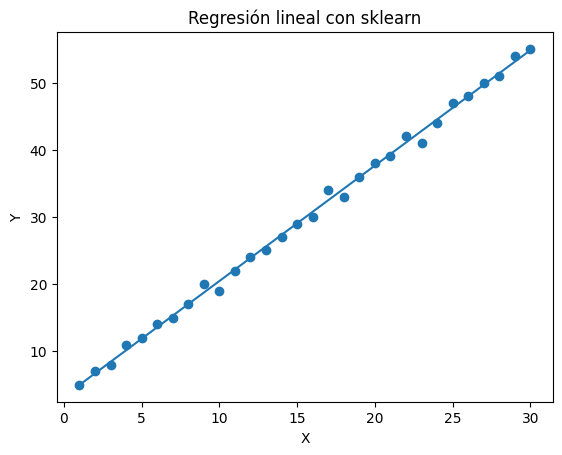

In [129]:
modelo = LinearRegression()
modelo.fit(x.reshape(-1, 1), y)

y_pred_sklearn = modelo.predict(x.reshape(-1, 1))

plt.scatter(x, y)
plt.plot(x, y_pred_sklearn)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regresión lineal con sklearn")
plt.show()